In [3]:
import pandas as pd
from exodash.utils.production_sector import ProductionSector, get_production_sector_df
from astronet.util import config_util
from astronet.astro_cnn_model import input_ds
import os

sectors = [82, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]
production_sectors = []
for sector in sectors:
    production_sectors.append(ProductionSector(sector=sector))

eval_files = []
for prod_sector in production_sectors:
    eval_files.extend(prod_sector.eval_files)

config = config_util.load_config("/pdo/users/pablomer/mnt/tess/models/vetting/20250502/cshallue/AstroCNNModelVetting_cshallue_20250502_000812")

# Set up evaluation datasets
eval_datasets = []
for file_pattern in eval_files:
    if ":" in file_pattern:
        name, pattern = file_pattern.split(":", 1)
    elif len(eval_files) == 1:
        name, pattern = "eval", file_pattern
    else:
        raise ValueError("Multiple datasets must be named as name:file_pattern")
    eval_datasets.append((name, pattern))



def build_astroid_to_view(ds, view_key="global_view", filter_ids=None):
    mapping = {}
    filter_set = set(filter_ids) if filter_ids is not None else None

    for features, identifiers in ds:
        ids = identifiers.numpy()
        views = features[view_key].numpy()  # shape: (B, ...)

        for astro_id, v in zip(ids, views):
            # normalize type
            if isinstance(astro_id, (bytes, bytearray)):
                astro_id = int(astro_id.decode())
            else:
                astro_id = int(astro_id)

            # apply filter if provided
            if filter_set is None or astro_id in filter_set:
                mapping[astro_id] = v

    return mapping

all_id_to_view = {}
for name, file_pattern in eval_datasets:
    dataset = input_ds.build_eval_dataset(
        file_pattern=file_pattern,
        input_config=config.inputs,
        batch_size=config.hparams.batch_size,
        include_identifiers=True,
        include_labels=False)
    astro_ids = []
    tic_ids = []
    planet_nos = []
    model_nos = []

    for batch in dataset:
        inputs, identifiers = batch
        astro_ids.extend([x for x in identifiers.numpy()])
    
    all_id_to_view.update(build_astroid_to_view(dataset))
        # tic_ids = [int(str(x)[:-2]) for x in astro_ids]
        # planet_nos = [int(str(x)[-2:]) for x in astro_ids]
        # model_nos = [0 for x in astro_ids]
        # print(identifiers)
id_to_view = all_id_to_view

2026-02-03 00:01:28.017523: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-03 00:01:32.148420: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.
2026-02-03 00:01:32.604871: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2026-02-03 00:01:32.893071: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start abo

In [4]:
df = get_production_sector_df(sectors, custom_model='/pdo/astronet-data/models/vetting/experimental/pablomer/dec2025_cad_scat_v5_duration24/20251217/pablomer-2k-nopretrained/', sector_to_astronet_scores_override={})
df.head(10)
print(len(id_to_view))
print(len(df))


2026-02-03 00:01:43.203906: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [1]
	 [[{{node Placeholder/_0}}]]
2026-02-03 00:01:43.576268: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [4]
	 [[{{node Placeholder/_0}}]]
2026-02-03 00:01:44.701985: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [4]
	 [[{{n

33863
30014


In [5]:
print(list(df.columns))

# filter for good signal
print(len(df_filtered))

['astro_id', 'tic_id', 'planetno', 'disp_p', 'disp_e', 'disp_n', 'disp_j', 'fc_0', 'fc_1', 'fc_2', 'fc_3', 'fc_4', 'fc_5', 'fc_6', 'fc_7', 'fc_8', 'fc_9', 'fc_10', 'fc_11', 'fc_12', 'fc_13', 'fc_14', 'fc_15', 'fc_16', 'fc_17', 'fc_18', 'fc_19', 'fc_20', 'fc_21', 'fc_22', 'fc_23', 'fc_24', 'fc_25', 'fc_26', 'fc_27', 'fc_28', 'fc_29', 'fc_30', 'fc_31', 'fc_32', 'fc_33', 'fc_34', 'fc_35', 'fc_36', 'fc_37', 'fc_38', 'fc_39', 'fc_40', 'fc_41', 'fc_42', 'fc_43', 'fc_44', 'fc_45', 'fc_46', 'fc_47', 'fc_48', 'fc_49', 'fc_50', 'fc_51', 'fc_52', 'fc_53', 'fc_54', 'fc_55', 'fc_56', 'fc_57', 'fc_58', 'fc_59', 'fc_60', 'fc_61', 'fc_62', 'fc_63', 'fc_64', 'fc_65', 'fc_66', 'fc_67', 'fc_68', 'fc_69', 'fc_70', 'fc_71', 'fc_72', 'fc_73', 'fc_74', 'fc_75', 'fc_76', 'fc_77', 'fc_78', 'fc_79', 'fc_80', 'fc_81', 'fc_82', 'fc_83', 'fc_84', 'fc_85', 'fc_86', 'fc_87', 'fc_88', 'fc_89', 'fc_90', 'fc_91', 'fc_92', 'fc_93', 'fc_94', 'fc_95', 'fc_96', 'fc_97', 'fc_98', 'fc_99', 'fc_100', 'fc_101', 'fc_102', 'fc_1

NameError: name 'df_filtered' is not defined

In [8]:
%matplotlib inline

In [30]:
import numpy as np
import matplotlib.pyplot as plt
def _plot_view(view: np.ndarray, astro_id: int) -> plt.Figure:
    phase = np.linspace(0, 1, len(view), endpoint=False)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(phase, view, marker='.', linestyle='-')
    ax.set_xlabel("Phase")
    ax.set_ylabel("Normalized flux")
    ax.set_title(f"Astro ID {astro_id}")
    ax.grid(True)
    fig.tight_layout()
    plt.show()


In [47]:
import numpy as np

def extract_tail_metrics(view,
                         frac=0.08,
                         cap_hw=300,
                         halfdepth_frac=0.5,
                         recovery_level=0.2,
                         eps=1e-4):
    """
    Extract all dust-tail-related metrics from a canonicalized 1D flux view.
    Returns a dict of metrics.
    """
    v = np.asarray(view, dtype=np.float32)
    g = np.maximum(0.0, -v)  # deficit
    n = g.size

    c = int(np.argmax(g))
    peak = g[c]

    metrics = {
        "center_idx": c,
        "peak_deficit": float(peak),
        "valid": False,
    }

    if not np.isfinite(peak) or peak <= 0:
        return metrics

    # --- transit window ---
    thr = peak * frac

    L = c
    steps = 0
    while L > 0 and steps < cap_hw and g[L] >= thr:
        L -= 1
        steps += 1

    R = c
    steps = 0
    while R < n - 1 and steps < cap_hw and g[R] >= thr:
        R += 1
        steps += 1

    hwL = c - L
    hwR = R - c
    hw = min(hwL, hwR)

    metrics.update({
        "hw_left": hwL,
        "hw_right": hwR,
        "hw_min": hw,
    })

    if hw < 15:
        return metrics

    left  = g[c - hw:c][::-1]
    right = g[c:c + hw]

    # --- half-depth width ratio ---
    thr_hd = peak * halfdepth_frac
    WL = np.where(left  >= thr_hd)[0]
    WR = np.where(right >= thr_hd)[0]

    wl = (WL[-1] + 1) if len(WL) else np.nan
    wr = (WR[-1] + 1) if len(WR) else np.nan
    metrics["wr_wl_halfdepth"] = float(wr / wl) if wl > 0 else np.nan

    # --- ingress / egress slope ratio ---
    k = max(6, hw // 30)
    k = min(k, hw)

    s_in  = (left[0]  - left[k-1])  / max(k-1, 1)
    s_out = (right[0] - right[k-1]) / max(k-1, 1)

    metrics["slope_ratio_ingress_egress"] = float(s_in / (s_out + 1e-6))

    # --- recovery time ratio ---
    def t_recover(x):
        idx = np.where(x <= peak * recovery_level)[0]
        return idx[0] if len(idx) else hw

    tL = t_recover(left)
    tR = t_recover(right)
    metrics["recovery_time_ratio_20pct"] = float(tR / max(tL, 1))

    # --- asymmetry area ---
    metrics["asym_area"] = float(np.trapz(left - right))

    # --- exponential tail fit ---
    m = right > eps
    metrics["n_points_tail_fit"] = int(np.sum(m))

    if np.sum(m) >= 10:
        t = np.arange(hw, dtype=np.float32)[m]
        y = np.log(right[m])
        slope = np.polyfit(t, y, 1)[0]
        metrics["tau_egress_exp"] = float(-1.0 / slope) if slope < 0 else np.nan
    else:
        metrics["tau_egress_exp"] = np.nan

    metrics["valid"] = True
    return metrics


def export_all_metrics(id_to_view,
                       frac=0.08,
                       cap_hw=300):
    """
    Returns:
      metrics_dict: astro_id -> metrics dict
    """
    out = {}
    for astro_id, view in id_to_view.items():
        m = extract_tail_metrics(view, frac=frac, cap_hw=cap_hw)
        m["astro_id"] = astro_id
        out[astro_id] = m
    return out


import pandas as pd

metrics_dict = export_all_metrics(id_to_view)
df_metrics = pd.DataFrame.from_dict(metrics_dict, orient="index")
df_metrics.reset_index(drop=True, inplace=True)

df_metrics.head()

candidates = df_metrics[
    (df_metrics["valid"]) &
    (df_metrics["slope_ratio_ingress_egress"] > 1.6) &
    (df_metrics["recovery_time_ratio_20pct"] > 1.6) &
    (df_metrics["tau_egress_exp"] > 25) &
    (df_metrics["astro_id"].isin(df_filtered["astro_id"]))
].sort_values("tau_egress_exp", ascending=False)

candidates[[
    "astro_id",
    "tau_egress_exp",
    "slope_ratio_ingress_egress",
    "recovery_time_ratio_20pct",
    "wr_wl_halfdepth",
]]

,astro_id,tau_egress_exp,slope_ratio_ingress_egress,recovery_time_ratio_20pct,wr_wl_halfdepth
16693,3463437501,129.780354,2.508341,4.833333,1.380952
20437,30625986101,92.998045,8.744001,1.700000,2.428571
22388,46391132101,74.603682,2.715249,1.875000,2.727273
22870,86126219101,25.688232,2.046716,2.062500,2.250000


In [32]:
import numpy as np
import pandas as pd

# ----------------------------
# Signature for similarity search (fixed length)
# ----------------------------
def _resample_1d(x, m):
    x = np.asarray(x, dtype=np.float32)
    if x.size == 0:
        return np.zeros(m, dtype=np.float32)
    if x.size == 1:
        return np.full(m, x[0], dtype=np.float32)
    xp = np.linspace(0.0, 1.0, x.size, dtype=np.float32)
    xq = np.linspace(0.0, 1.0, m, dtype=np.float32)
    return np.interp(xq, xp, x).astype(np.float32)


def tail_signature(view, frac=0.08, cap_hw=300, m=160, min_hw=12, fallback_hw=60):
    """
    Fixed-length (m) asymmetry signature on deficit around transit.
    If gated window is too narrow, falls back to a fixed half-width.
    """
    v = np.asarray(view, dtype=np.float32)
    g = np.maximum(0.0, -v)  # deficit, baseline ~0
    n = g.size

    c = int(np.argmax(g))
    peak = g[c]
    if not np.isfinite(peak) or peak <= 0:
        return None

    thr = peak * float(frac)

    # gated window
    L = c
    steps = 0
    while L > 0 and steps < cap_hw and g[L] >= thr:
        L -= 1
        steps += 1

    R = c
    steps = 0
    while R < n - 1 and steps < cap_hw and g[R] >= thr:
        R += 1
        steps += 1

    hw = int(min(c - L, R - c))

    # fallback if too narrow
    if hw < min_hw:
        hw = int(min(fallback_hw, c, n - c - 1))

    if hw < min_hw:
        return None

    left  = g[c - hw:c][::-1]   # center outward
    right = g[c:c + hw]

    left_r  = _resample_1d(left,  m)
    right_r = _resample_1d(right, m)
    return (left_r - right_r).astype(np.float32)

def make_weights(m):
    """
    Heavier weight near center (ingress) and mid-range (tail).
    """
    x = np.linspace(0, 1, m, dtype=np.float32)
    w = np.ones_like(x)
    w += 4.0 * np.exp(-0.5 * ((x - 0.08) / 0.06) ** 2)   # sharp ingress region
    w += 2.0 * np.exp(-0.5 * ((x - 0.45) / 0.18) ** 2)   # tail region
    return w

def weighted_l2(a, b, w):
    d = a - b
    return float(np.sqrt(np.sum(w * d * d)))

# ----------------------------
# Similarity search API
# ----------------------------
def similarity_search_tail(
    id_to_view,
    df_metrics,
    target_id,
    topn=30,
    # signature params
    sig_frac=0.08,
    sig_cap_hw=300,
    sig_m=160,
    # constraint params (set to None to disable a constraint)
    min_slope_ratio=1.6,
    min_recovery_ratio=1.6,
    min_tau=25.0,
    min_wrwl=1.2,
    # optional: prefilter to top-K by a cheap score before full distance
    prefilter_k=None,
):
    """
    Returns:
      results_df: DataFrame with astro_id, distance, and selected metrics
    """
    # Metrics lookup
    mdf = df_metrics.set_index("astro_id")

    if target_id not in id_to_view:
        raise KeyError(f"target_id {target_id} not in id_to_view")
    if target_id not in mdf.index:
        raise KeyError(f"target_id {target_id} not in df_metrics")

    q_view = id_to_view[target_id]
    q_sig = tail_signature(q_view, frac=sig_frac, cap_hw=sig_cap_hw, m=sig_m)
    if q_sig is None:
        raise ValueError("Target signature is None (no usable transit window).")

    w = make_weights(sig_m)

    # Candidate pool = valid rows only
    pool = mdf[mdf["valid"] == True].copy()

    # Apply parameterized constraints
    if min_slope_ratio is not None:
        pool = pool[pool["slope_ratio_ingress_egress"] >= float(min_slope_ratio)]
    if min_recovery_ratio is not None:
        pool = pool[pool["recovery_time_ratio_20pct"] >= float(min_recovery_ratio)]
    if min_tau is not None:
        pool = pool[np.isfinite(pool["tau_egress_exp"]) & (pool["tau_egress_exp"] >= float(min_tau))]
    if min_wrwl is not None:
        pool = pool[np.isfinite(pool["wr_wl_halfdepth"]) & (pool["wr_wl_halfdepth"] >= float(min_wrwl))]

    # remove target itself if present
    pool = pool[pool.index != target_id]

    # Optional prefilter: keep only top-K by a cheap score
    # (prioritize stronger tails and sharper ingress)
    if prefilter_k is not None and len(pool) > int(prefilter_k):
        score = (
            0.8 * pool["tau_egress_exp"].fillna(0) +
            1.0 * pool["slope_ratio_ingress_egress"].fillna(0) +
            1.0 * pool["recovery_time_ratio_20pct"].fillna(0) +
            0.2 * pool["wr_wl_halfdepth"].fillna(0)
        )
        pool = pool.loc[score.sort_values(ascending=False).head(int(prefilter_k)).index]

    # Compute distances
    rows = []
    for aid in pool.index:
        view = id_to_view.get(aid, None)
        if view is None:
            continue

        sig = tail_signature(view, frac=sig_frac, cap_hw=sig_cap_hw, m=sig_m)
        if sig is None:
            continue

        d = weighted_l2(sig, q_sig, w)

        r = pool.loc[aid].to_dict()
        r.update({"astro_id": aid, "distance": d})
        rows.append(r)

    results = pd.DataFrame(rows)
    if results.empty:
        return results

    results = results.sort_values("distance", ascending=True).head(topn)

    # Put key columns first (keep the rest too)
    front = [
        "astro_id", "distance",
        "tau_egress_exp",
        "slope_ratio_ingress_egress",
        "recovery_time_ratio_20pct",
        "wr_wl_halfdepth",
        "peak_deficit",
        "hw_left", "hw_right", "hw_min",
        "asym_area",
        "n_points_tail_fit",
    ]
    cols = [c for c in front if c in results.columns] + [c for c in results.columns if c not in front]
    return results[cols]

# ----------------------------
# Convenience: run + plot
# ----------------------------
def show_top_similar(id_to_view, df_metrics, target_id, topn=10, plot_n=5, **kwargs):
    res = similarity_search_tail(
        id_to_view=id_to_view,
        df_metrics=df_metrics,
        target_id=target_id,
        topn=topn,
        **kwargs
    )
    if res.empty:
        print("No results (try relaxing constraints).")
        return res

    print(res[[
        "astro_id", "distance",
        "tau_egress_exp",
        "slope_ratio_ingress_egress",
        "recovery_time_ratio_20pct",
        "wr_wl_halfdepth"
    ]])

    # plot target + top matches
    _plot_view(id_to_view[target_id], target_id)
    for aid in res["astro_id"].head(plot_n).tolist():
        _plot_view(id_to_view[aid], aid)

    return res


len 201 min -1.0 max 0.06837756186723709 median 0.0
6116
6116
       astro_id  distance  tau_egress_exp  slope_ratio_ingress_egress  \
28  34672720901  2.662660       26.841876                    3.377389   
36  43367286401  2.704820       25.362536                    6.303404   
16  15201964601  2.771693       25.447750                    1.205781   
4    8463689001  2.932703       62.325177                    3.183339   
47  76988529401  3.212808       29.019098                    1.708233   
39  44719328701  3.263451       21.466105                   15.359173   
13  14146252001  3.303249       34.474029                    4.872041   
11  12749333201  3.353050       21.049417                    1.985386   
19  21702837001  3.397700       25.312510                    1.859729   
14  14473770801  3.555895       28.371384                   96.723233   
3    8230712201  3.797250       20.018626                    1.792890   
10  12686962501  3.836414       24.915395                    5

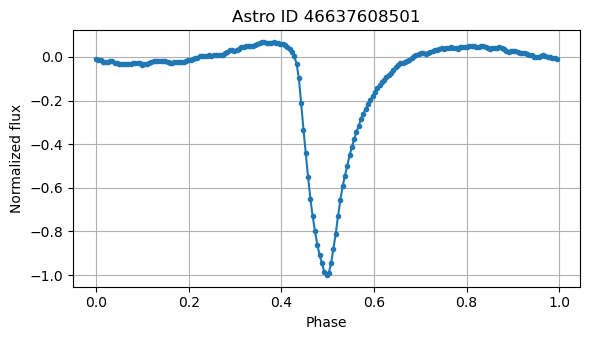

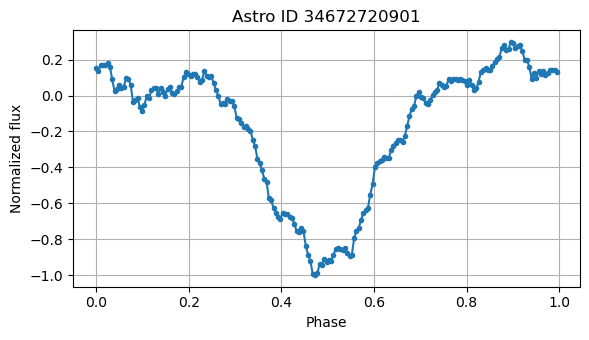

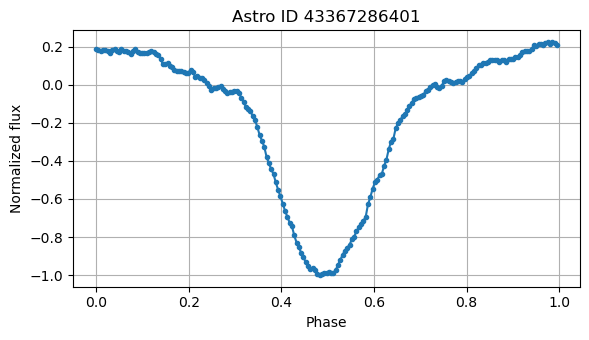

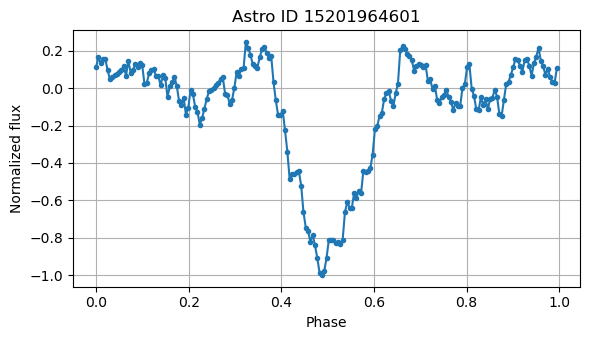

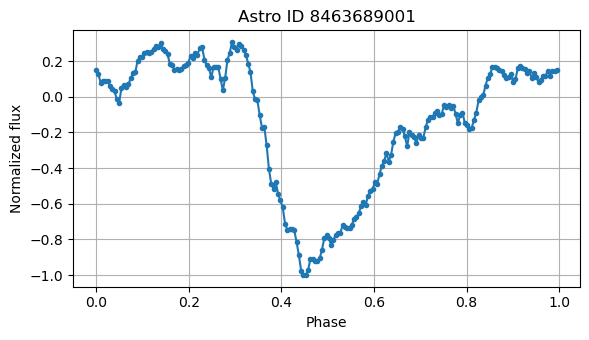

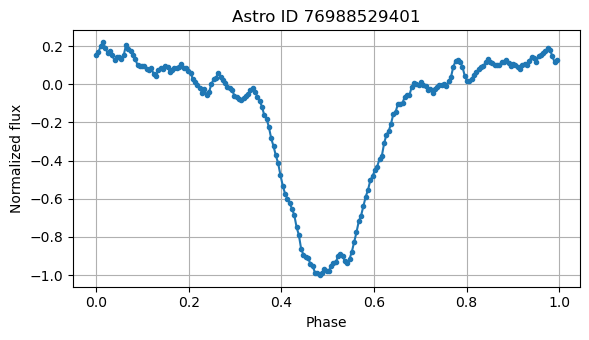

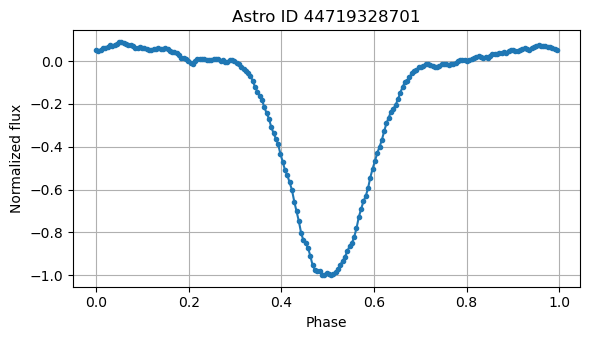

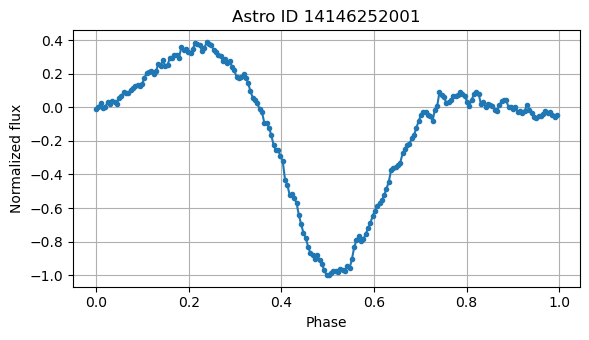

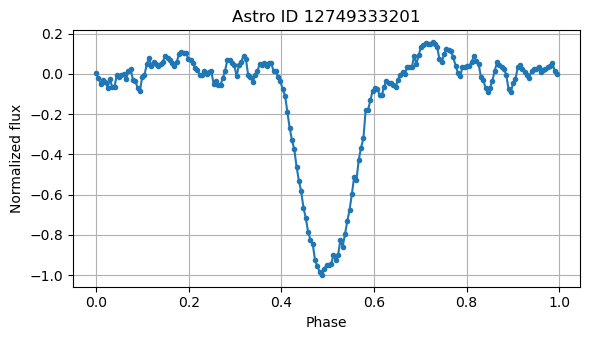

In [55]:
target_astro_id = 46637608501
v = np.asarray(id_to_view[target_astro_id], dtype=np.float32)
print("len", len(v), "min", float(np.min(v)), "max", float(np.max(v)), "median", float(np.median(v)))

df_filtered = df[(df['snr'] > 20) & (df['planetno'] == 1) & (df['disp_j'] < 0.4)]
df_joined = df_filtered.merge(
    df_metrics,
    on="astro_id",
    how="left"   # keeps only rows in df_filtered
)

print(len(df_joined))
df_joined = df_joined[df_joined['astro_id'].isin(df_filtered['astro_id'])]

print(len(df_joined))

res = show_top_similar(
    id_to_view,
    df_joined,
    target_astro_id,
    topn=30,
    plot_n=8,

    # signature parameters (windowing)
    sig_frac=0.03,
    sig_cap_hw=300,
    sig_m=160,

    # constraints: tighten these to be stricter
    min_slope_ratio=1.2,
    min_recovery_ratio=1.2,
    min_tau=20,
    min_wrwl=1.1,

    # optional speedup / stability
    prefilter_k=200
)

In [12]:
from typing import Optional
import numpy as np
from astronet.preprocess import preprocess
import matplotlib.pyplot as plt


def get_lightcurve(astro_id: int, aperture: Optional[str] = None) -> tuple[np.ndarray, np.ndarray]:
    aperture_key_map = {
        "s": "SAP_FLUX_SML",
        "m": "SAP_FLUX_MID",
        "l": "SAP_FLUX_LAG",
        None: "SAP_FLUX",
    }
    global tce_table
    matching_tces = tce_table[tce_table["Astro ID"] == astro_id] # tce_table.where(tce_table["Astro ID"] == astro_id)
    try:
        _, tce = next(matching_tces.iterrows())
    except StopIteration as e:
        raise ValueError(f"Astro ID not found: {astro_id}") from e
    if "MinT" not in tce:
        tce["MinT"] = -np.inf
    if "MaxT" not in tce:
        tce["MaxT"] = np.inf
    return preprocess.read_and_process_light_curve(
        data_dir,
        aperture_key_map[aperture],
        tce.File,
        tce.MinT,
        tce.MaxT,
    )

def view_lc(view, id):
    phase = np.linspace(0, 1, len(view), endpoint=False)  # phase from 0 to 1
    plt.figure(figsize=(6, 4))
    plt.plot(phase, view, marker='.', linestyle='-')
    plt.xlabel("Phase")
    plt.ylabel("Normalized flux")
    plt.title(f"Astro ID {id}")
    plt.gca().invert_yaxis()  # optional: transits go down
    plt.grid(True)
    plt.show()

In [14]:
from light_curve_util.light_curve_metrics import export_all_metrics
from light_curve_util.similarity_search import show_top_similar
target_astro_id = 46637608501

# 1) metrics
df_metrics = export_all_metrics(id_to_view, window_frac=0.08, cap_hw=300)

# 2) join with your filters (keep only df_filtered rows)
df_filtered = df#df[(df['snr'] > 20) & (df['planetno'] == 1) & (df['disp_j'] < 0.4)]

df_joined = df_filtered.merge(df_metrics, on="astro_id", how="left")

# # 3) similarity search
# res = show_top_similar(
#     id_to_view,
#     df_joined,
#     target_astro_id,
#     topn=30,
#     plot_n=8,

#     # signature parameters (windowing)
#     sig_frac=0.03,
#     sig_cap_hw=300,
#     sig_m=160,

#     # constraints: tighten these to be stricter
#     min_slope_ratio=1.2,
#     min_recovery_ratio=1.2,
#     min_tau=20,
#     min_wrwl=1.1,

#     min_egress_monotonic=0.75,     # egress mostly decreasing
#     max_egress_smoothness=0.08,    # smoother egress
#     min_ingress_impulse=0.35,      # sharper ingress concentration

#     # optional speedup / stability
#     prefilter_k=200,
# )


In [9]:
from IPython.display import display, clear_output
import ipywidgets as widgets

In [18]:
from light_curve_util.similarity_search import show_top_similar  # your module

def run_search(
    sig_frac,
    sig_m,
    min_slope_ratio,
    min_recovery_ratio,
    min_tau,
    min_wrwl,
    prefilter_k,
    topn,
    plot_n,
    min_mono,
    max_smooth,
    min_impulse,
):
    clear_output(wait=True)

    res = show_top_similar(
        id_to_view=id_to_view,
        df=df_joined,
        target_astro_id=target_astro_id,
        topn=int(topn),
        plot_n=int(plot_n),

        sig_frac=float(sig_frac),
        sig_cap_hw=300,
        sig_m=int(sig_m),

        min_slope_ratio=float(min_slope_ratio),
        min_recovery_ratio=float(min_recovery_ratio),
        min_tau=float(min_tau),
        min_wrwl=float(min_wrwl),

        prefilter_k=int(prefilter_k),
        min_egress_monotonic=float(min_mono),
        max_egress_smoothness=float(max_smooth),
        min_ingress_impulse=float(min_impulse),
    )
    return res


In [20]:
sig_frac_slider = widgets.FloatSlider(
    value=0.03, min=0.01, max=0.12, step=0.005,
    description="sig_frac", readout_format=".3f", continuous_update=False
)

sig_m_slider = widgets.IntSlider(
    value=160, min=64, max=256, step=16,
    description="sig_m", continuous_update=False
)

min_slope_slider = widgets.FloatSlider(
    value=1.2, min=1.0, max=3.0, step=0.05,
    description="min_slope", readout_format=".2f", continuous_update=False
)

min_recovery_slider = widgets.FloatSlider(
    value=1.2, min=1.0, max=4.0, step=0.05,
    description="min_recovery", readout_format=".2f", continuous_update=False
)

min_tau_slider = widgets.FloatSlider(
    value=20.0, min=0.0, max=80.0, step=1.0,
    description="min_tau", readout_format=".1f", continuous_update=False
)

min_wrwl_slider = widgets.FloatSlider(
    value=1.1, min=1.0, max=6.0, step=0.05,
    description="min_wrwl", readout_format=".2f", continuous_update=False
)

prefilter_slider = widgets.IntSlider(
    value=200, min=50, max=2000, step=50,
    description="prefilter_k", continuous_update=False
)

topn_slider = widgets.IntSlider(
    value=30, min=5, max=100, step=5,
    description="topn", continuous_update=False
)

plotn_slider = widgets.IntSlider(
    value=8, min=0, max=25, step=1,
    description="plot_n", continuous_update=False
)
min_mono_slider = widgets.FloatSlider(
    value=0.75, min=0.5, max=1.0, step=0.05,
    description="min_mono",
    readout_format=".2f",
    continuous_update=False
)

max_smooth_slider = widgets.FloatSlider(
    value=0.08, min=0.01, max=0.20, step=0.01,
    description="max_smooth",
    readout_format=".2f",
    continuous_update=False
)

min_impulse_slider = widgets.FloatSlider(
    value=0.35, min=0.1, max=0.8, step=0.05,
    description="min_impulse",
    readout_format=".2f",
    continuous_update=False
)
ui = widgets.VBox([
    widgets.HBox([sig_frac_slider, sig_m_slider]),
    widgets.HBox([min_slope_slider, min_recovery_slider]),
    widgets.HBox([min_tau_slider, min_wrwl_slider]),
    widgets.HBox([min_mono_slider, max_smooth_slider, min_impulse_slider]),
    widgets.HBox([prefilter_slider, topn_slider, plotn_slider]),
])

out = widgets.interactive_output(
    run_search,
    {
        "sig_frac": sig_frac_slider,
        "sig_m": sig_m_slider,
        "min_slope_ratio": min_slope_slider,
        "min_recovery_ratio": min_recovery_slider,
        "min_tau": min_tau_slider,
        "min_wrwl": min_wrwl_slider,
        "prefilter_k": prefilter_slider,
        "topn": topn_slider,
        "plot_n": plotn_slider,
        "min_mono": min_mono_slider,
        "max_smooth": max_smooth_slider,
        "min_impulse": min_impulse_slider,
    }
)

display(ui, out)



Output()